In [1]:
import pandas as pd

df = pd.read_excel('../data/Online Retail.xlsx')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [3]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cu

In [4]:
df.shape

(541909, 8)

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [7]:
df_clean = df.dropna(subset=['CustomerID'])
df_clean.shape

(406829, 8)

In [8]:
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean.shape

(397884, 8)

In [9]:
df_clean = df_clean.drop_duplicates()
df_clean.shape

(392692, 8)

In [10]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
import datetime as dt

# Set a reference date — one day after the last transaction in the dataset
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                      # Frequency
    'TotalPrice': 'sum'                                          # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


In [12]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


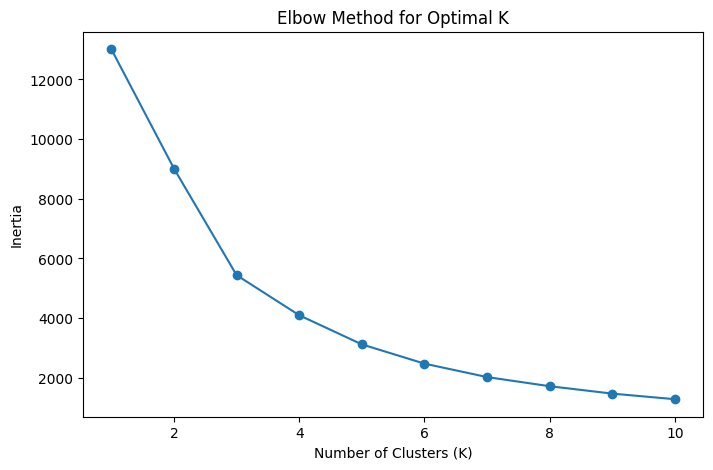

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

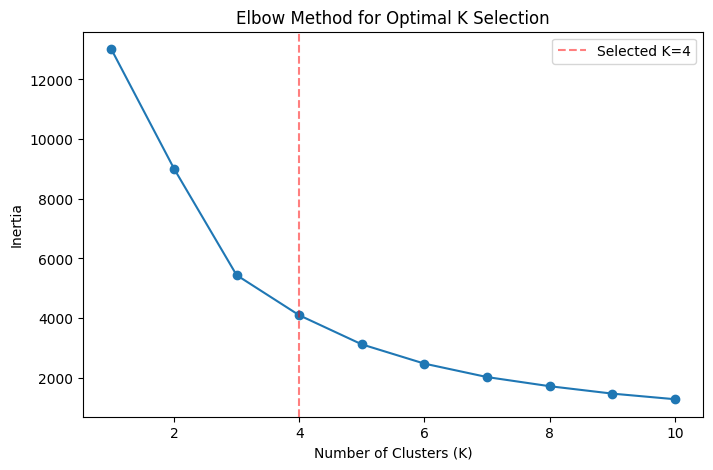

In [15]:
# Figure 4.1: Elbow Method Chart for Optimal K Selection

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Selected K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K Selection')
plt.legend()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

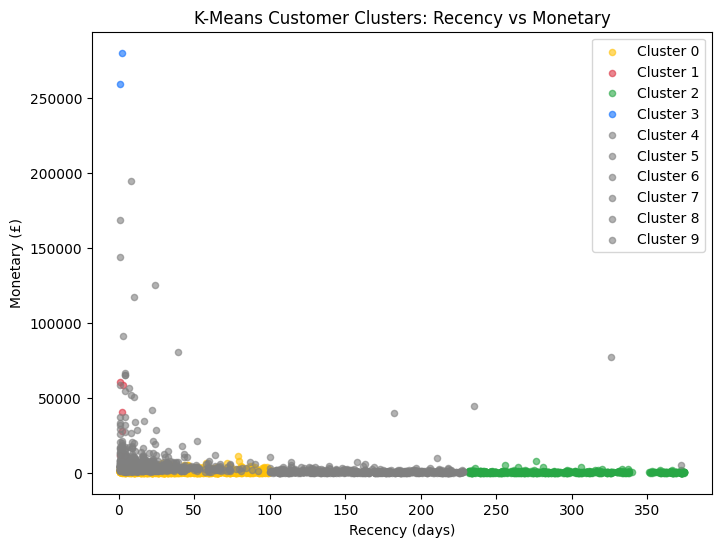

In [16]:
# Make sure rfm has a Cluster column from your existing kmeans model
# Figure 4.2: K-Means Customer Cluster Scatter Plot (Recency vs Monetary)

rfm['Cluster'] = kmeans.labels_

plt.figure(figsize=(8, 6))
colors = {0: '#ffc107', 1: '#dc3545', 2: '#28a745', 3: '#0d6efd'}  # adjust to match your actual cluster IDs
for cluster_id in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster_id]
    plt.scatter(subset['Recency'], subset['Monetary'], label=f'Cluster {cluster_id}',
                color=colors.get(cluster_id, 'gray'), alpha=0.6, s=20)

plt.xlabel('Recency (days)')
plt.ylabel('Monetary (£)')
plt.title('K-Means Customer Clusters: Recency vs Monetary')
plt.legend()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

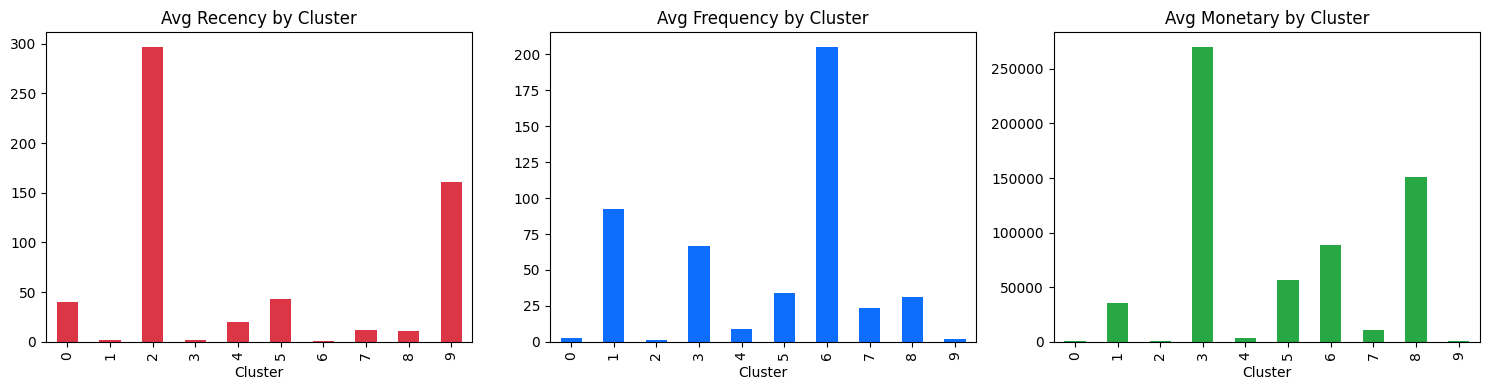

In [17]:
# Figure 4.3: Bar Chart of Average RFM Values per Cluster

cluster_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cluster_means['Recency'].plot(kind='bar', ax=axes[0], color='#dc3545', title='Avg Recency by Cluster')
cluster_means['Frequency'].plot(kind='bar', ax=axes[1], color='#0d6efd', title='Avg Frequency by Cluster')
cluster_means['Monetary'].plot(kind='bar', ax=axes[2], color='#28a745', title='Avg Monetary by Cluster')
for ax in axes:
    ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('rfm_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

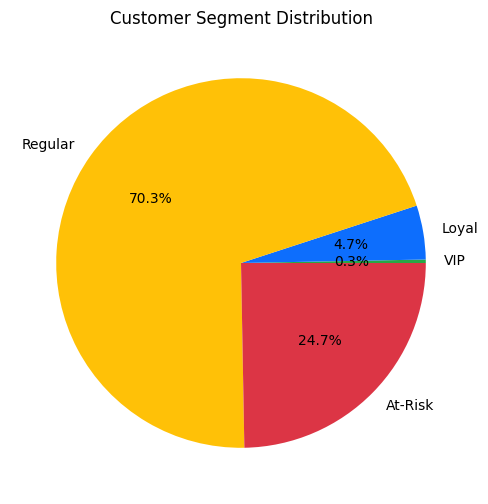

In [1]:
import matplotlib.pyplot as plt

# Figure 4.4: Segment distribution pie chart
segment_counts = {'VIP': 13, 'Loyal': 204, 'Regular': 3034, 'At-Risk': 1067}
plt.figure(figsize=(6, 6))
plt.pie(segment_counts.values(), labels=segment_counts.keys(), autopct='%1.1f%%',
        colors=['#28a745', '#0d6efd', '#ffc107', '#dc3545'])
plt.title('Customer Segment Distribution')
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
})

,Recency,Frequency,Monetary,Cluster
Cluster,,,,
0,43.702685,3.682711,1353.625312,3054
1,248.075914,1.552015,478.848773,1067
2,7.384615,82.538462,127187.959231,13
3,15.500000,22.333333,12690.500392,204


In [16]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(rfm_scaled, rfm['Cluster'])
db_score = davies_bouldin_score(rfm_scaled, rfm['Cluster'])
ch_score = calinski_harabasz_score(rfm_scaled, rfm['Cluster'])

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

Silhouette Score: 0.6162
Davies-Bouldin Index: 0.7542
Calinski-Harabasz Score: 3145.0585


In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

# See how many clusters were found and how many are noise
print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4284
-1      54
Name: count, dtype: int64


In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Remove noise points (-1) before evaluating
dbscan_mask = rfm['DBSCAN_Cluster'] != -1
dbscan_labels = rfm['DBSCAN_Cluster'][dbscan_mask]
rfm_scaled_db = rfm_scaled[dbscan_mask.values]

sil_db = silhouette_score(rfm_scaled_db, dbscan_labels)
db_db = davies_bouldin_score(rfm_scaled_db, dbscan_labels)
ch_db = calinski_harabasz_score(rfm_scaled_db, dbscan_labels)

print(f"DBSCAN Silhouette Score: {sil_db:.4f}")
print(f"DBSCAN Davies-Bouldin Index: {db_db:.4f}")
print(f"DBSCAN Calinski-Harabasz Score: {ch_db:.4f}")

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
n_clusters = len(set(rfm['DBSCAN_Cluster'])) - 1  # excludes noise (-1)
n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")
print("Evaluation metrics: Not applicable — only 1 cluster found")
print("Conclusion: DBSCAN is not suitable for this RFM dataset with default parameters")

DBSCAN Clusters found: 1
Noise points: 54
Evaluation metrics: Not applicable — only 1 cluster found
Conclusion: DBSCAN is not suitable for this RFM dataset with default parameters


In [19]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Fit GMM with K=4 (matching domain expectations)
gmm = GaussianMixture(n_components=4, random_state=42)
rfm['GMM_Cluster'] = gmm.fit_predict(rfm_scaled)

# Calculate Evaluation Metrics
gmm_sil = silhouette_score(rfm_scaled, rfm['GMM_Cluster'])
gmm_db = davies_bouldin_score(rfm_scaled, rfm['GMM_Cluster'])
gmm_ch = calinski_harabasz_score(rfm_scaled, rfm['GMM_Cluster'])

print(f"GMM - Silhouette: {gmm_sil:.4f}, Davies-Bouldin: {gmm_db:.4f}, Calinski-Harabasz: {gmm_ch:.4f}")

GMM - Silhouette: 0.1629, Davies-Bouldin: 1.6201, Calinski-Harabasz: 894.8307


In [22]:
from sklearn.cluster import AgglomerativeClustering

# Fit Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
rfm['Agg_Cluster'] = agg.fit_predict(rfm_scaled)

# Calculate Evaluation Metrics
agg_sil = silhouette_score(rfm_scaled, rfm['Agg_Cluster'])
agg_db = davies_bouldin_score(rfm_scaled, rfm['Agg_Cluster'])
agg_ch = calinski_harabasz_score(rfm_scaled, rfm['Agg_Cluster'])

print(f"Agglomerative - Silhouette: {agg_sil:.4f}, Davies-Bouldin: {agg_db:.4f}, Calinski-Harabasz: {agg_ch:.4f}")

Agglomerative - Silhouette: 0.6077, Davies-Bouldin: 0.8090, Calinski-Harabasz: 2926.8848


In [25]:
import os
import joblib

# Set exact directory path based on your system layout
ML_DIR = '/home/aromasodu-taiwo-victor/Documents/smartseg_system/ml'
os.makedirs(ML_DIR, exist_ok=True)

# Save the scaler and model
joblib.dump(scaler, os.path.join(ML_DIR, 'rfm_scaler.pkl'))
joblib.dump(kmeans, os.path.join(ML_DIR, 'kmeans_model.pkl'))

print(f"Artifacts successfully saved to: {ML_DIR}")

Artifacts successfully saved to: /home/aromasodu-taiwo-victor/Documents/smartseg_system/ml


In [26]:
import os
import joblib
import pandas as pd
import numpy as np

# 1. Save artifacts to your actual project directory
ML_DIR = '/home/aromasodu-taiwo-victor/Documents/smartseg_system/ml'
os.makedirs(ML_DIR, exist_ok=True)

scaler_path = os.path.join(ML_DIR, 'rfm_scaler.pkl')
model_path = os.path.join(ML_DIR, 'kmeans_model.pkl')

joblib.dump(scaler, scaler_path)
joblib.dump(kmeans, model_path)
print("Artifacts successfully saved!")

# 2. Inspect Centroids to determine label alignment
# Inverse transform centroids to original RFM units (Days, Orders, $)
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_), 
    columns=['Recency', 'Frequency', 'Monetary']
)

print("\n=== Cluster Centroids (Unscaled Values) ===")
print(centroids)
print("===========================================\n")

# 3. Dynamically assign cluster IDs based on centroid metrics
# (Matches the cluster numbers to actual customer behavior)
vip_id = centroids['Monetary'].idxmax()
at_risk_id = centroids['Recency'].idxmax()

# Get remaining two cluster indices for Loyal and Regular
remaining_ids = [i for i in range(4) if i not in (vip_id, at_risk_id)]

# Compare frequency among remaining to differentiate Loyal from Regular
if centroids.loc[remaining_ids[0], 'Frequency'] > centroids.loc[remaining_ids[1], 'Frequency']:
    loyal_id, regular_id = remaining_ids[0], remaining_ids[1]
else:
    loyal_id, regular_id = remaining_ids[1], remaining_ids[0]

cluster_mapping = {
    vip_id: "VIP Customer",
    loyal_id: "Loyal Customer",
    regular_id: "Regular Customer",
    at_risk_id: "At-Risk Customer"
}

print("Dynamic Cluster Label Mapping:")
for cid, label in cluster_mapping.items():
    print(f"  Cluster {cid} -> {label}")

# 4. Perform Pre-Production Inference Test
test_customers = pd.DataFrame([
    {"Customer": "High Spender / VIP Candidate", "Recency": 5, "Frequency": 85, "Monetary": 12500.0},
    {"Customer": "Frequent Buyer / Loyal Candidate", "Recency": 12, "Frequency": 40, "Monetary": 3200.0},
    {"Customer": "Average Shopper / Regular Candidate", "Recency": 45, "Frequency": 8, "Monetary": 450.0},
    {"Customer": "Churn Risk / At-Risk Candidate", "Recency": 280, "Frequency": 1, "Monetary": 35.0}
])

X_raw = test_customers[['Recency', 'Frequency', 'Monetary']]

# Preserve column names during scaling to prevent sklearn feature name warnings
X_scaled = pd.DataFrame(scaler.transform(X_raw), columns=['Recency', 'Frequency', 'Monetary'])

test_customers['Predicted_Cluster_ID'] = kmeans.predict(X_scaled)
test_customers['Segment_Label'] = test_customers['Predicted_Cluster_ID'].map(cluster_mapping)

print("\n=== Inference Test Results ===")
print(test_customers[['Customer', 'Recency', 'Frequency', 'Monetary', 'Segment_Label']])


Artifacts successfully saved!

=== Cluster Centroids (Unscaled Values) ===
      Recency  Frequency       Monetary
0   43.702685   3.682711    1353.625312
1  248.075914   1.552015     478.848773
2    7.384615  82.538462  127187.959231
3   15.500000  22.333333   12690.500392

Dynamic Cluster Label Mapping:
  Cluster 2 -> VIP Customer
  Cluster 3 -> Loyal Customer
  Cluster 0 -> Regular Customer
  Cluster 1 -> At-Risk Customer

=== Inference Test Results ===
                              Customer  Recency  Frequency  Monetary  \
0         High Spender / VIP Candidate        5         85   12500.0   
1     Frequent Buyer / Loyal Candidate       12         40    3200.0   
2  Average Shopper / Regular Candidate       45          8     450.0   
3       Churn Risk / At-Risk Candidate      280          1      35.0   

      Segment_Label  
0    Loyal Customer  
1    Loyal Customer  
2  Regular Customer  
3  At-Risk Customer  
